<a href="https://colab.research.google.com/github/ekaratnida/Applied-machine-learning/blob/master/Week03-MLR/Lab3-1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Multivariate linear regresion


In [19]:
!pip install ipython-autotime
%load_ext autotime

time: 635 µs (started: 2026-08-25 07:48:23 +00:00)


## 1.1 Normal equation (Numpy version)

In [1]:
import numpy as np
np.set_printoptions(precision=2)
from sklearn.datasets import make_regression

x, y = make_regression(n_samples=100000, n_features=1000, noise=2, random_state=123)

In [5]:
x_b = np.c_[np.ones((x.shape[0],1)),x]

In [2]:
x.shape

(100000, 1000)

In [ ]:

#x = np.array([[0,2,3],[1,6,8]]).T
#x = np.array([[0,1],[2,6],[3,8]]) #x1, x2
#y = np.array([1,1,4])

x_b = np.c_[np.ones((x.shape[0],1)),x]

#call inverse function from linear algebra module
theta = np.linalg.pinv(x_b.T.dot(x_b)).dot(x_b.T).dot(y)
print("theta = ", theta)

#predict trainned x
xtest = np.array([[4,9]])
xtest_b = np.c_[np.ones((xtest.shape[0],1)),xtest]
y_p = xtest_b.dot(theta)
print("y predict = ",y_p)
'''
import matplotlib.pyplot as plt

#Create the title
exp = ""
plus = "+"
for t in range(len(theta)):
  if t == len(theta)-1:
    plus = ""
  if t == 0:
    xterm = ""
  else:
    xterm = r"$x_"+str(t)+"$"
  exp += str(np.round(theta[t],2)) + xterm + plus
#end create the title

plt.title("y = "+exp)
data = sorted(zip(x[:,0],y))
print("data = ", data)
x_val = [x[0] for x in data]
y_val = [x[1] for x in data]

plt.plot(x_val, y_val, "b.")
plt.xlabel(r'$x_1$')
plt.ylabel(r'$y$')

plt.show()
'''

In [21]:
'''ax = plt.figure().add_subplot(projection='3d')

xs = x[:,0]
ys = x[:,1]
zs = y

for x1, x2, _y in zip(xs, ys, zs):
  label = '(%d, %d, %d)' % (x1, x2, _y)
  ax.text(x1, x2, _y, label, 'x')
  ax.scatter(x1, x2, zs=_y)

ax.set_xlim(-2, 6)
ax.set_ylim(0, 6)
ax.set_zlim(-2, 8)
ax.set_xlabel(r'$X_1$')
ax.set_ylabel(r'$X_2$')
ax.set_zlabel('Y')

plt.show()'''

KeyboardInterrupt: 

Error in callback <function _draw_all_if_interactive at 0x7fd226967100> (for post_execute):


KeyboardInterrupt: 

Error in callback <function flush_figures at 0x7fd226964540> (for post_execute):


KeyboardInterrupt: 

time: 33.4 s (started: 2026-08-25 07:07:40 +00:00)


Exercise1 <br>
1.1 Change a number of features to 4 (x1,x2,x3,x4) </br>


# **Sklearn**

In [25]:
import numpy as np
from sklearn.linear_model import LinearRegression

lin_reg = LinearRegression()
lin_reg.fit(x, y)
print(lin_reg.intercept_, " , ", lin_reg.coef_)

#prediction
y_p = lin_reg.predict(xtest)
print("y predict = ",y_p)

0.0034304169681703897  ,  [97.33 37.83]
y predict =  [729.78]
time: 88.9 ms (started: 2026-08-25 07:10:33 +00:00)


# **Batch Gradient descent (Multiple linear regression)**


In [7]:
def cost_function(theta, x, y, N): #mse
  y_hat = x.dot(theta)
  c = (1/N)*np.sum((y_hat-y)**2)
  return c

In [17]:
import random
import math
def gradient_descent(alpha, x, y, ep=0.001, max_iter=10000):
  converged = False
  iter = 0
  N = x.shape[0] # number of samples
  print("Num of data = ",N)

  # initial theta
  theta =  np.random.random((x.shape[1],1))
  print("Init theta.shape = ",theta.shape)

  # total error, J(theta)
  J = cost_function(theta, x, y, N)
  print("First J = ",J)

  # Iterate Loop
  while not converged:

    y_hat = x.dot(theta)
    diff = y_hat - y
    grad = x.T.dot(diff)

    theta = theta - alpha * (1/N) * (grad)

    #assert theta.shape == (3,1) #This line makes sure that the shape of theta is still be the same.

    # error
    J2 = cost_function(theta, x, y, N)

    if abs(J-J2) <= ep:
        print("       Converged, iterations: ", iter, "/", max_iter)
        converged = True

    J = J2   # update error s
    iter += 1  # update iter

    if iter == max_iter:
        print('       Max iterations exceeded!')
        converged = True

    if math.floor(iter % 100) == 0:
      # This block is now only for printing debug info at certain intervals.
      print("iter = ",iter, ", error = ", J)

  #print("End converged iter = ",iter)
  return theta

In [18]:
if __name__ == '__main__':

  print("start main")
  print(x_b.shape)
  y = y.reshape(-1,1)
  print(y.shape)

  alpha = 0.01 # learning rate
  #Training process
  theta = gradient_descent(alpha, x_b, y, ep=0.000000000001, max_iter=1000000)
  print ("Theta = ", theta)

  #predict trainned x
  #xtest = np.array([[4,9]])
  #xtest_b = np.c_[np.ones((xtest.shape[0],1)),xtest]
  #y_p = xtest_b.dot(theta)
  #print("y predict = ",y_p)



start main
(100000, 1001)
(100000, 1)
Num of data =  100000
Init theta.shape =  (1001, 1)
First J =  30591.46619917234
iter =  100 , error =  4102.689445914553
iter =  200 , error =  576.8668498564911
iter =  300 , error =  87.29358037696056
iter =  400 , error =  16.5254487810559
iter =  500 , error =  5.9125546192627345
iter =  600 , error =  4.268251290892886
iter =  700 , error =  4.006211537997092
iter =  800 , error =  3.963438792988235
iter =  900 , error =  3.9563142632287644
iter =  1000 , error =  3.9551071592424343
iter =  1100 , error =  3.9548996797868177
iter =  1200 , error =  3.9548635806245813
iter =  1300 , error =  3.954857234114622
iter =  1400 , error =  3.954856108330217
iter =  1500 , error =  3.954855907078922
iter =  1600 , error =  3.9548558708582067
iter =  1700 , error =  3.9548558643004657
iter =  1800 , error =  3.9548558631069395
       Converged, iterations:  1889 / 1000000
Theta =  [[-3.58e-03]
 [-4.41e-04]
 [-6.52e-03]
 ...
 [ 6.52e+01]
 [ 2.16e-04]
 [

# Stochastic GD
## Your turn :)

In [70]:
import random
import math
def sgd(alpha, x, y, ep=0.001, max_iter=10000):
  converged = False
  iter = 0
  N = x.shape[0] # number of samples
  print("Num of data = ",N)

  # initial theta
  theta =  np.random.random((x.shape[1],1))
  print("Init theta.shape = ",theta.shape)

  # total error, J(theta)
  J = cost_function(theta, x, y, N)
  print("First J = ",J)

  dataSize = list(range(0,x.shape[0]))
  #print("dataSize = ",dataSize)

  # Iterate Loop
  while not converged:

    #select one row
    ri = random.randint(0,len(dataSize))
    ri = dataSize[ri]
    dataSize.remove(ri)
    #print("x[ri] shape ",x[ri].shape)

    xr = x[ri].reshape(1,-1)
    #print("xr shape ",xr.shape) #1 x 1001
    y_hat = xr.dot(theta) #theta = 1001 x 1

    diff = y_hat - y[ri]
    #print("diff.shape", diff.shape) # 1 x 1
    diff = diff.reshape(-1,1)
    grad = xr.T.dot(diff) # xr.T -> 1001 x 1 dot 1 x 1

    theta = theta - alpha * (1/N) * (grad)

    #assert theta.shape == (3,1) #This line makes sure that the shape of theta is still be the same.

    alpha = alpha/(1+(alpha*0.1*iter))

    # error
    J2 = cost_function(theta, x, y, N)

    if abs(J-J2) <= ep:
        print("       Converged, iterations: ", iter, "/", max_iter)
        converged = True

    J = J2   # update error s
    iter += 1  # update iter

    if iter == max_iter:
        print('       Max iterations exceeded!')
        converged = True

    if math.floor(iter % 1000) == 0:
      # This block is now only for printing debug info at certain intervals.
      print("iter = ",iter, ", error = ", J)
      print("alpha ",alpha)
      print("dataSize len",len(dataSize))

  #print("End converged iter = ",iter)
  return theta

time: 11.7 ms (started: 2026-08-25 08:34:44 +00:00)


In [72]:
if __name__ == '__main__':
  print("start main")
  print(x_b.shape)
  y = y.reshape(-1,1)
  print(y.shape)
  alpha = 0.1
  theta = sgd(alpha, x_b, y, ep=0.000000000001, max_iter=1000000)
  print ("Theta = ", theta)


start main
(100000, 1001)
(100000, 1)
Num of data =  100000
Init theta.shape =  (1001, 1)
First J =  30602.35104898288
iter =  1000 , error =  30601.56909891328
alpha  2.0016012810248223e-05
dataSize len 99000
iter =  2000 , error =  30601.56302015671
alpha  5.00225101295583e-06
dataSize len 98000


KeyboardInterrupt: 

time: 3min 9s (started: 2026-08-25 08:38:22 +00:00)


# Mini-batch GD (b = 1000)
## Your turn :)

# Polynomial regression
Reference: https://towardsdatascience.com/machine-learning-polynomial-regression-with-python-5328e4e8a386

In [8]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# Importing the dataset
df = pd.read_csv('https://raw.githubusercontent.com/ekaratnida/Applied-machine-learning/master/Week03-MLR/Position_Salaries.csv')
X = df.iloc[:, 1:2].values
y = df.iloc[:, 2].values
print(df.head())

            Position  Level  Salary
0   Business Analyst      1   45000
1  Junior Consultant      2   50000
2  Senior Consultant      3   60000
3            Manager      4   80000
4    Country Manager      5  110000
time: 252 ms (started: 2026-08-25 06:52:36 +00:00)


[  45000   50000   60000   80000  110000  150000  200000  300000  500000
 1000000]


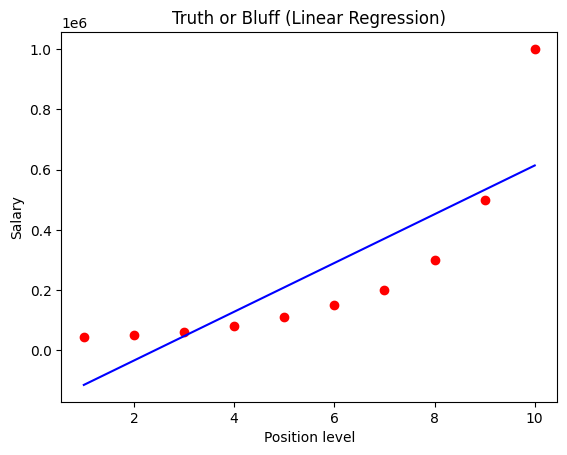

time: 394 ms (started: 2026-08-25 06:52:36 +00:00)


In [9]:
# Fitting Linear Regression to the dataset
from sklearn.linear_model import LinearRegression
lin_reg = LinearRegression()
lin_reg.fit(X, y)
print(y)
# Visualizing the Linear Regression results

plt.scatter(X, y, color='red')
plt.plot(X, lin_reg.predict(X), color='blue')
plt.title('Truth or Bluff (Linear Regression)')
plt.xlabel('Position level')
plt.ylabel('Salary')
plt.show()


[[   1.    1.    1.    1.]
 [   1.    2.    4.    8.]
 [   1.    3.    9.   27.]
 [   1.    4.   16.   64.]
 [   1.    5.   25.  125.]
 [   1.    6.   36.  216.]
 [   1.    7.   49.  343.]
 [   1.    8.   64.  512.]
 [   1.    9.   81.  729.]
 [   1.   10.  100. 1000.]]


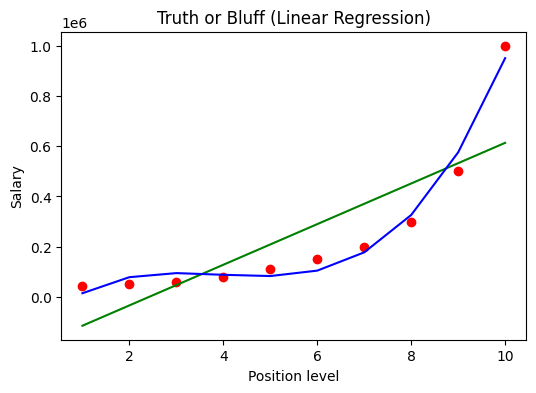

time: 468 ms (started: 2026-08-25 06:52:36 +00:00)


In [10]:
# Fitting Polynomial Regression to the dataset
from sklearn.preprocessing import PolynomialFeatures
poly_reg = PolynomialFeatures(degree=3)
X_poly = poly_reg.fit_transform(X)
print(X_poly)
pol_reg = LinearRegression()
pol_reg.fit(X_poly, y)

# Visualizing the Polymonial Regression results
plt.figure(figsize=(6,4))
plt.scatter(X, y, color='red')
plt.plot(X, lin_reg.predict(X), color='green')
plt.plot(X, pol_reg.predict(X_poly), color='blue')
plt.title('Truth or Bluff (Linear Regression)')
plt.xlabel('Position level')
plt.ylabel('Salary')
plt.show()


In [11]:
# Predicting a new result with Linear Regression
print(lin_reg.predict([[5.5]]))

# Predicting a new result with Polymonial Regression
print(pol_reg.predict(poly_reg.fit_transform([[5.5]])))

[249500.]
[89187.5]
time: 10.6 ms (started: 2026-08-25 06:52:37 +00:00)
